In [31]:
# Getting IBM backend connected

from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
import dynamic_broadcast as db
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(linewidth=200)
np.set_printoptions(precision=3, suppress=True)

service = QiskitRuntimeService(name="mprest1")



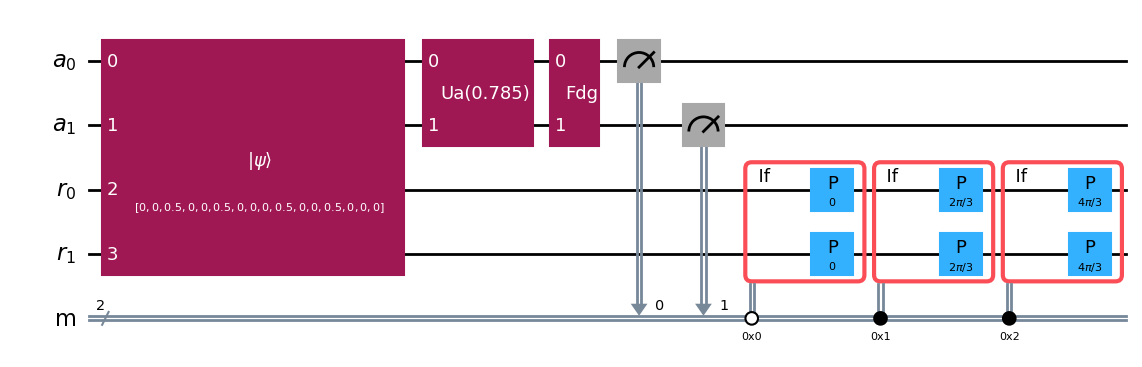

In [35]:
# Testing functions in library

circuit = db.generate_qiskit_circuit(1, 2, [np.pi/4])
circuit.draw("mpl")

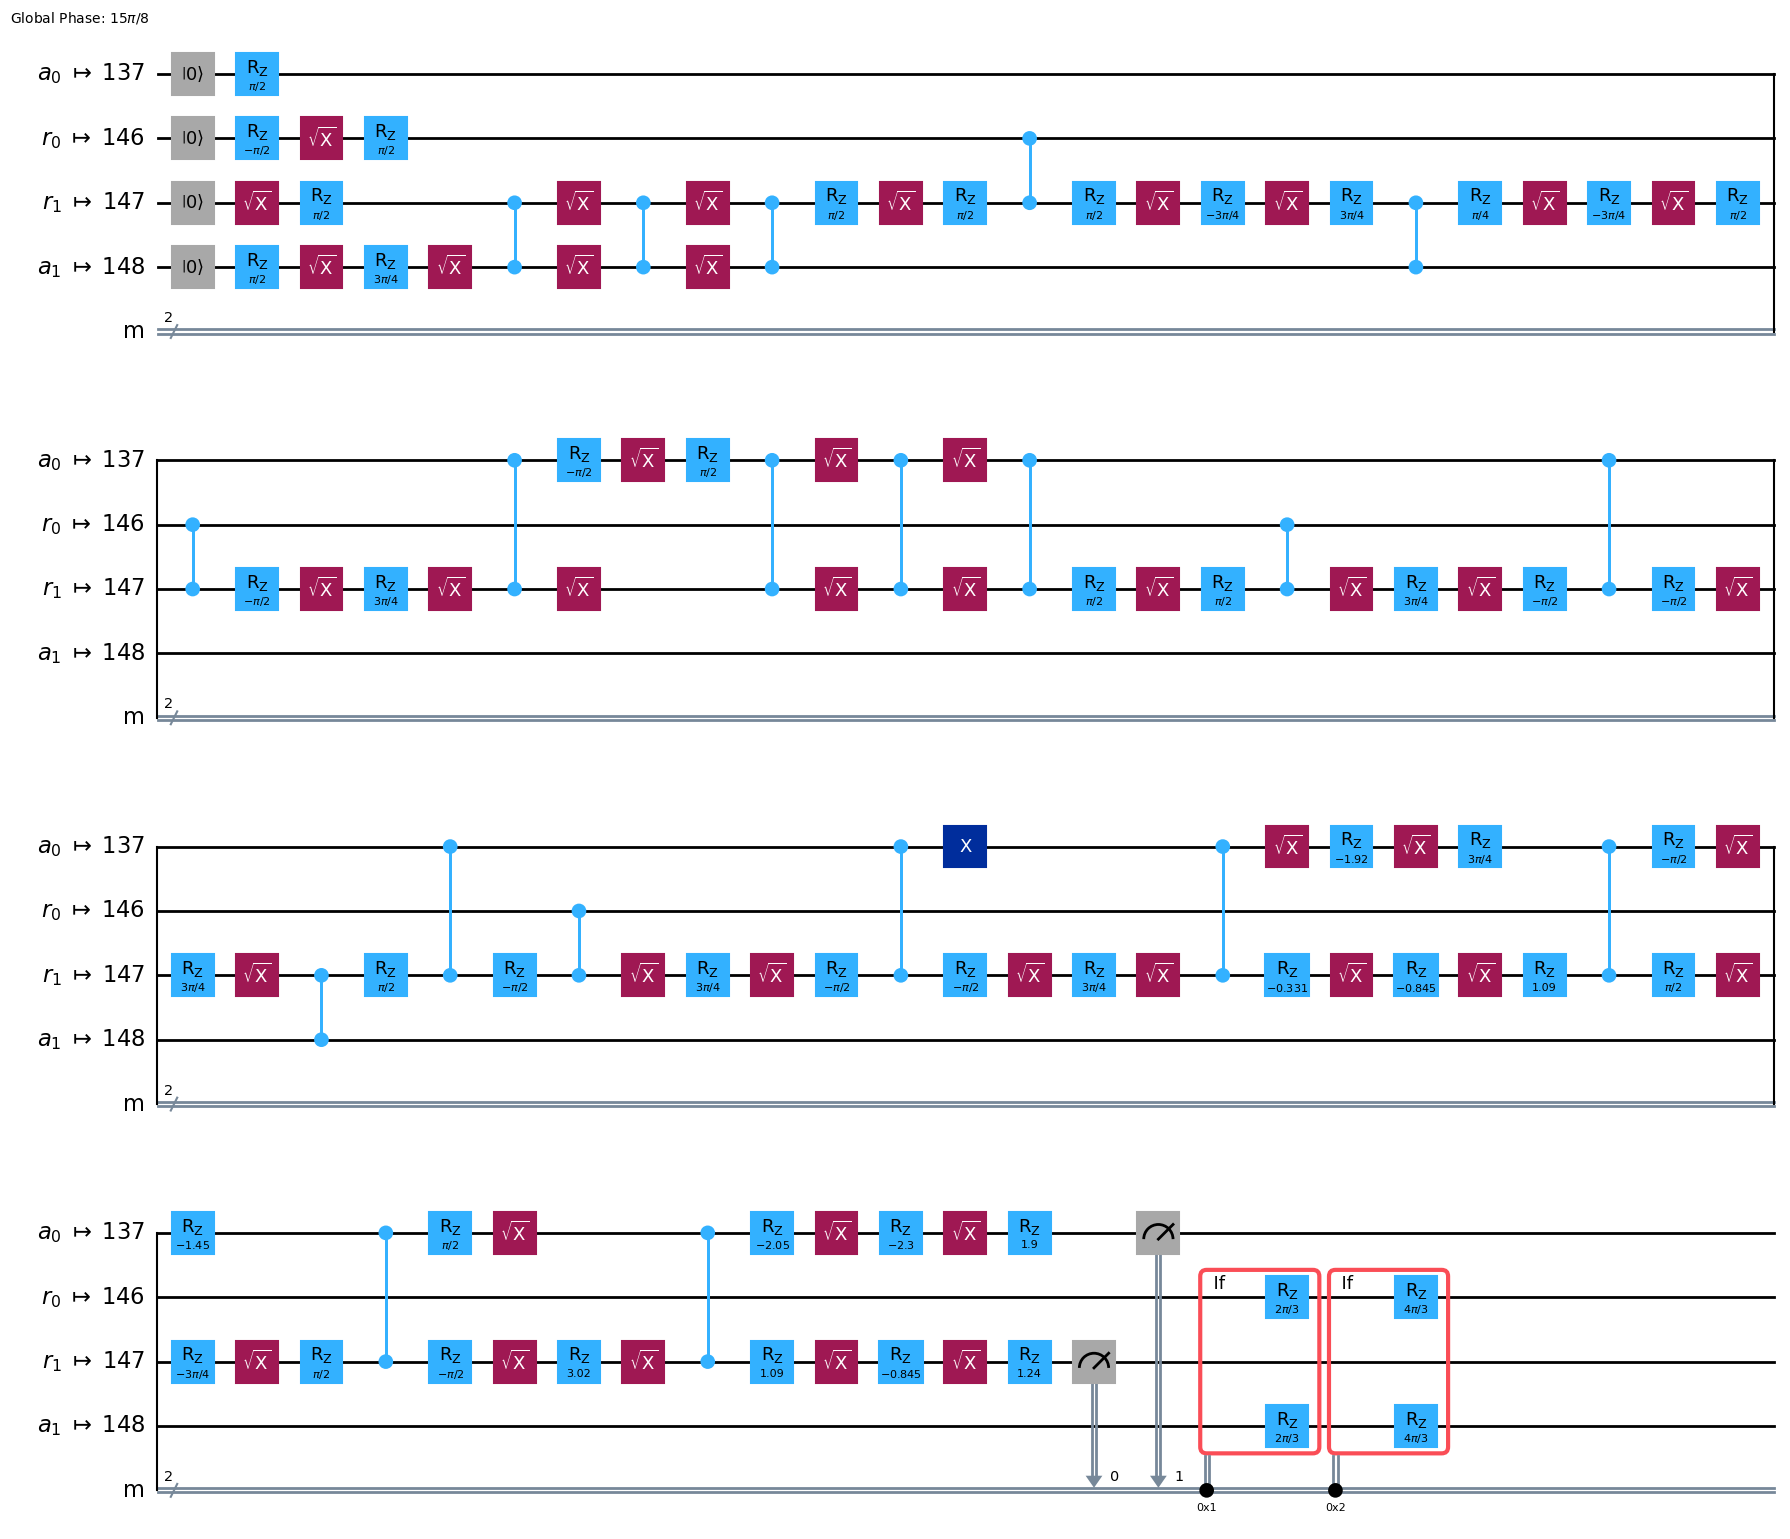

In [36]:


backend = service.least_busy(simulator=False, operational=True)

# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(circuit)

isa_circuit.draw("mpl", idle_wires=False)

In [ ]:
# Constructing the sampler

sampler = Sampler(mode=backend)

# One pub, with one circuit to run
job = sampler.run([isa_circuit])

# # Use the job ID to retrieve your job data later
# print(f">>> Job ID: {job.job_id()}")

ValueError: An invalid Sampler pub-like was given (<class 'qiskit._accelerate.circuit.CircuitInstruction'>). If you want to run a single circuit, you need to wrap it with `[]` like `sampler.run([circuit])` instead of `sampler.run(circuit)`.

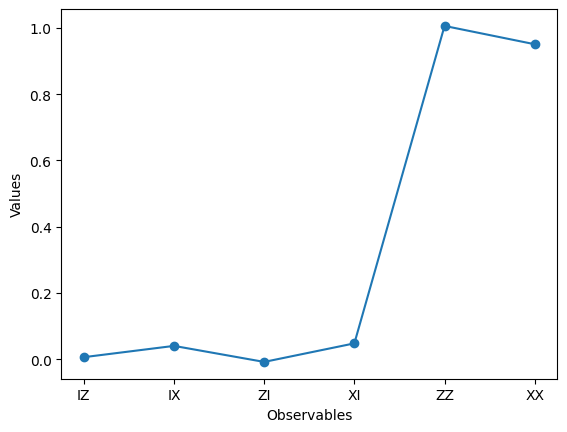

In [19]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()

# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]

# Plot the result

values = pub_result.data.evs

errors = pub_result.data.stds

# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()